In [53]:
import matplotlib.font_manager as fm

# 설치된 폰트 리스트 출력
font_list = [f.name for f in fm.fontManager.ttflist]
print(font_list)

# 특정 이름이 포함된 폰트 찾기 (예: 'Gothic'이 들어간 폰트)
print([f for f in font_list if 'Gothic' in f])

['STIXNonUnicode', 'STIXSizeTwoSym', 'DejaVu Sans Mono', 'cmr10', 'STIXSizeOneSym', 'DejaVu Sans Mono', 'DejaVu Sans Mono', 'DejaVu Sans', 'DejaVu Serif', 'STIXSizeOneSym', 'STIXSizeFourSym', 'STIXGeneral', 'STIXSizeFiveSym', 'STIXGeneral', 'cmex10', 'cmmi10', 'DejaVu Sans Display', 'STIXSizeFourSym', 'cmsy10', 'STIXNonUnicode', 'STIXNonUnicode', 'DejaVu Sans', 'STIXSizeThreeSym', 'STIXGeneral', 'STIXGeneral', 'STIXNonUnicode', 'DejaVu Serif Display', 'cmtt10', 'DejaVu Serif', 'cmb10', 'STIXSizeTwoSym', 'DejaVu Serif', 'DejaVu Sans', 'DejaVu Sans', 'DejaVu Sans Mono', 'cmss10', 'DejaVu Serif', 'STIXSizeThreeSym', 'DejaVu Serif', 'DejaVu Sans Mono', 'DejaVu Serif', 'Ubuntu', 'Ubuntu', 'NanumSquareRound', 'Ubuntu Mono', 'DejaVu Sans', 'Ubuntu', 'DejaVu Sans', 'DejaVu Math TeX Gyre', 'NanumGothic', 'NanumBarunGothic', 'NanumBarunGothic', 'NanumSquare', 'DejaVu Sans', 'DejaVu Sans', 'Ubuntu Mono', 'DejaVu Sans', 'NanumGothic', 'DejaVu Serif', 'DejaVu Sans Mono', 'DejaVu Sans', 'DejaVu Sans

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('Bank Customer Churn Prediction.csv')
data.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [55]:
churn = data[data['churn'] == 1]
stay = data[data['churn'] == 0]

In [128]:
data.active_member.describe()

count    10000.000000
mean         0.515100
std          0.499797
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: active_member, dtype: float64

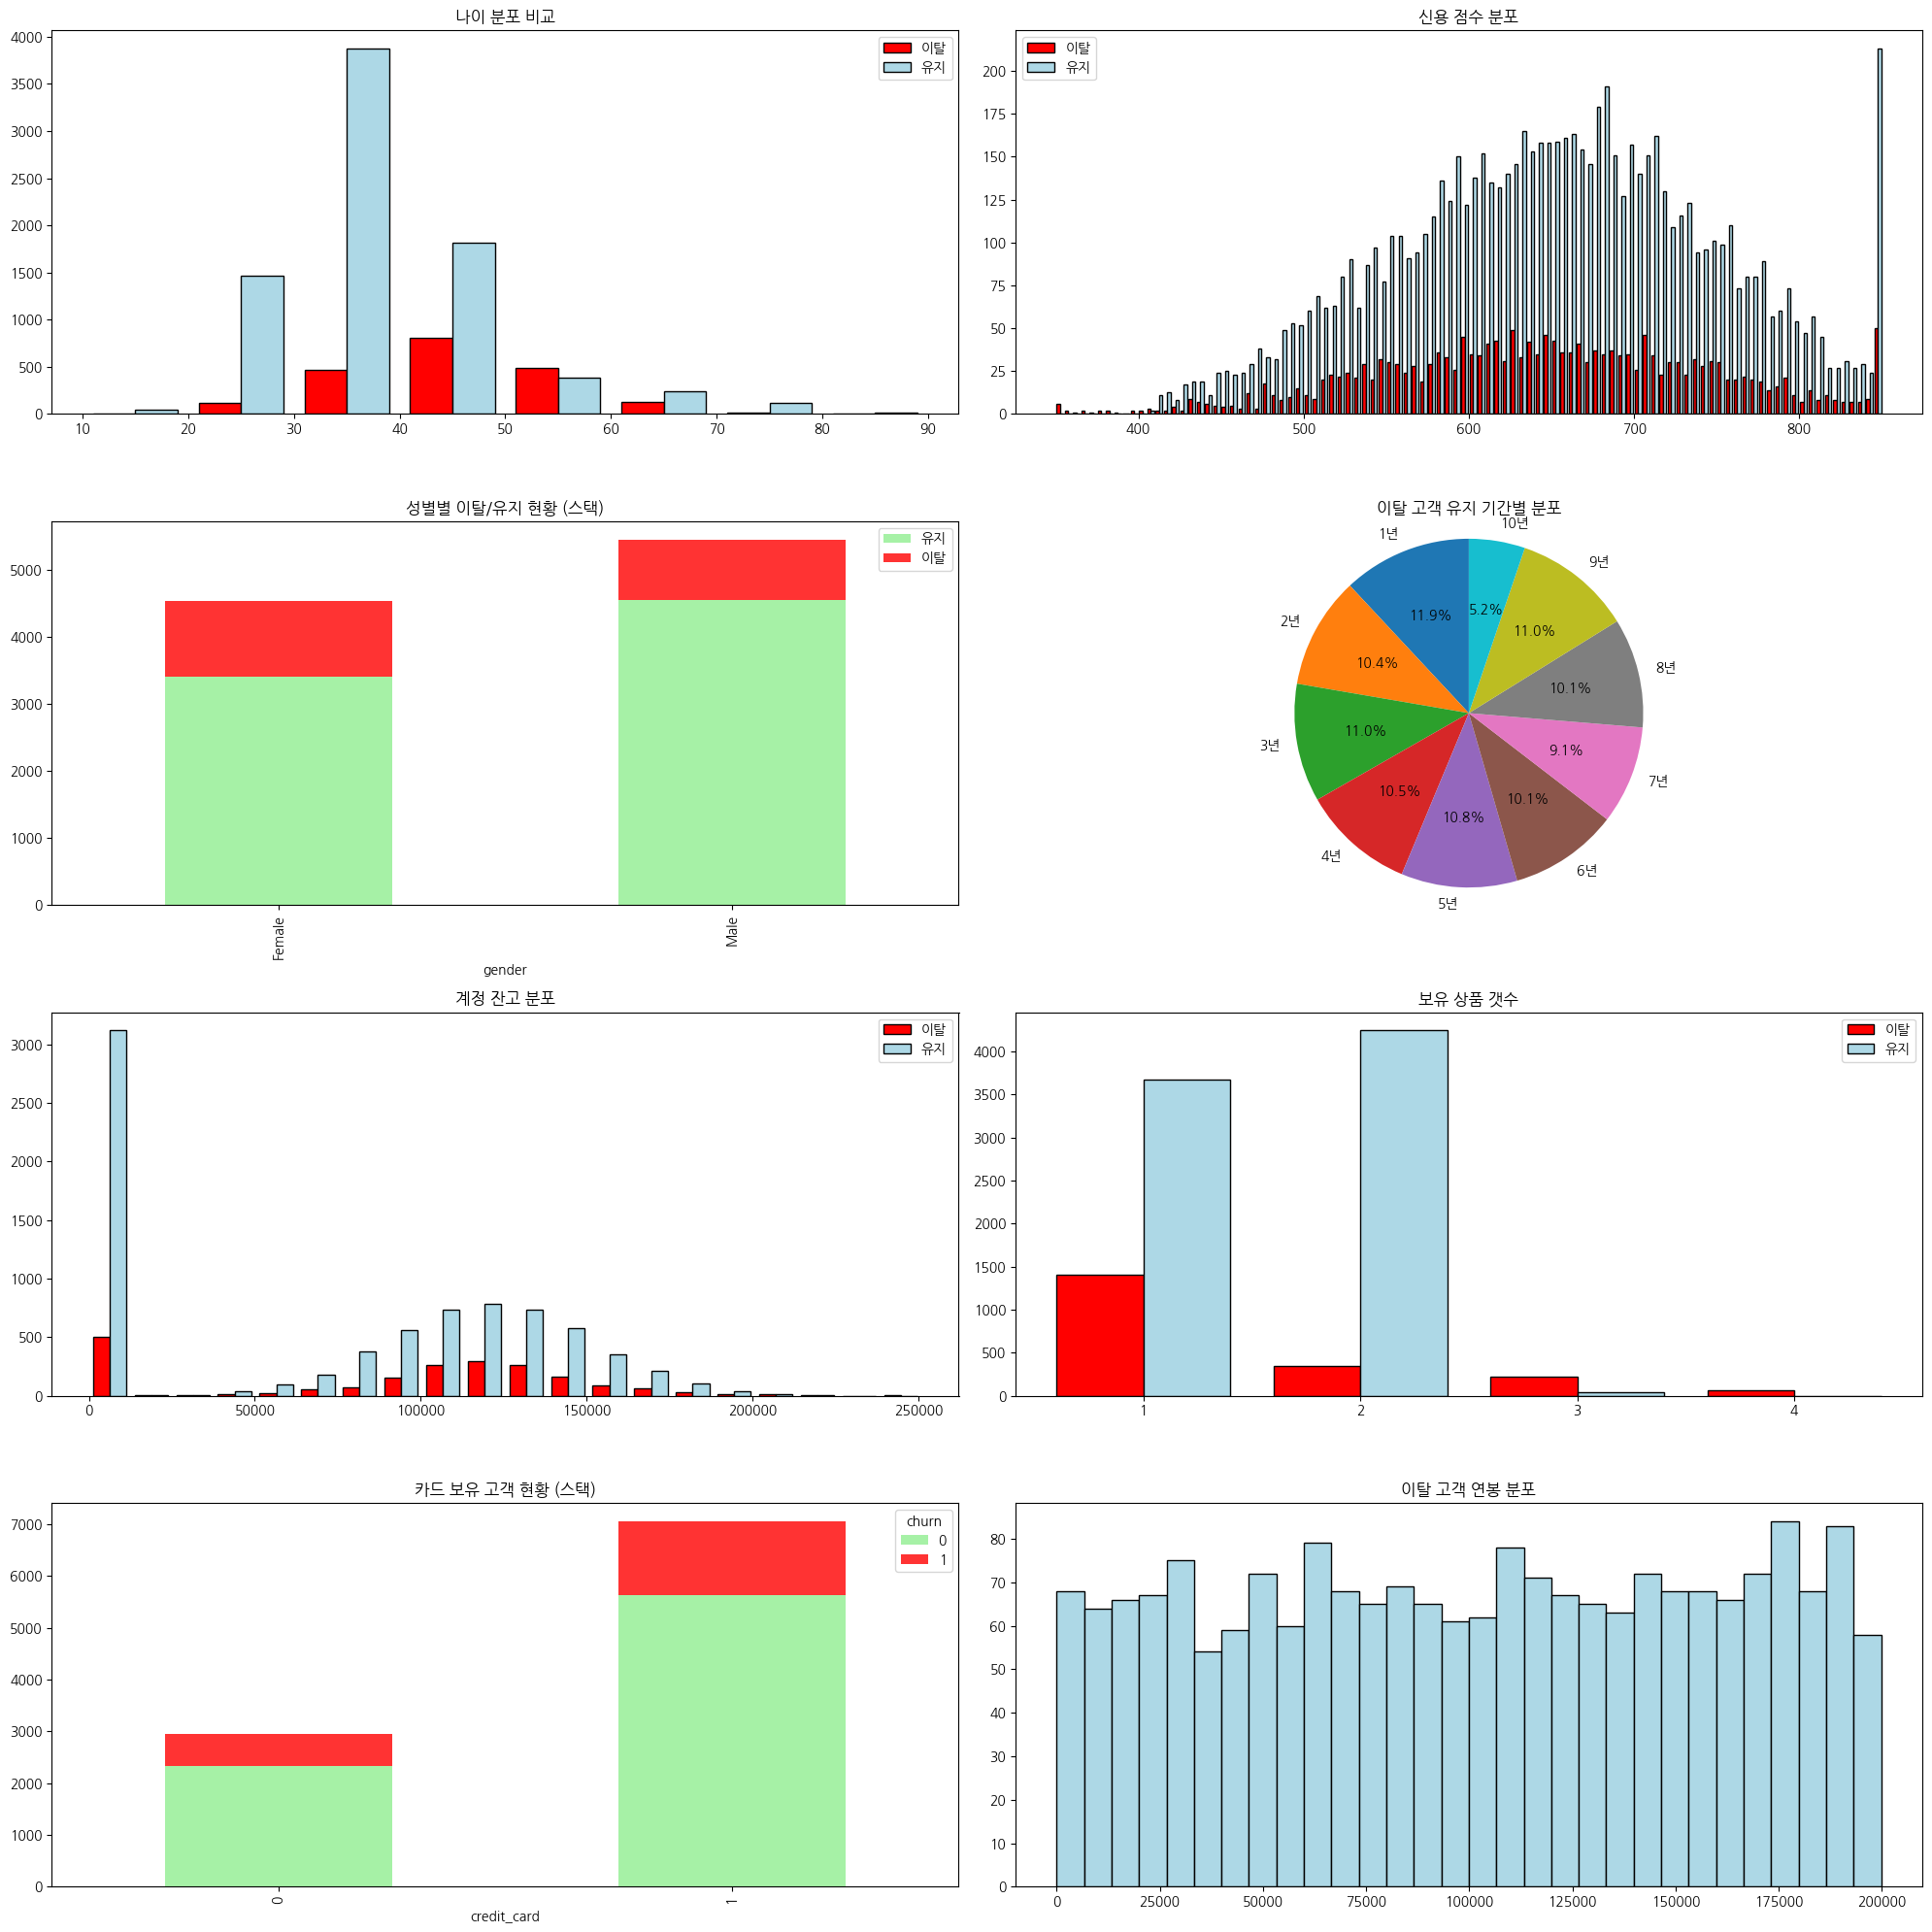

In [131]:
fig, axes = plt.subplots(4, 2, figsize=(20, 20))


ages = axes[0, 0]
ages.set_title('나이 분포 비교')
ages_bins = [x*10 for x in range(1, 10)]
ages.hist([churn.age, stay.age], bins=ages_bins, color=['red','lightblue'], edgecolor='black', label=['이탈', '유지'])
ages.legend()


credit_score = axes[0, 1]
credit_score.set_title('신용 점수 분포')
credit_score.hist([churn.credit_score, stay.credit_score], bins=100, color=['red','lightblue'], edgecolor='black', label=['이탈', '유지'])
credit_score.legend()

gender_ax = axes[1,0]
gender_ax.set_title('성별별 이탈/유지 현황 (스택)')
gender_counts = data.groupby(['gender', 'churn']).size().unstack(fill_value=0)
gender_counts.plot(kind='bar', ax=gender_ax, stacked=True, 
                   color=['lightgreen', 'red'], alpha=0.8)
gender_ax.legend(['유지', '이탈'])

tenure = axes[1, 1]
tenure.set_title('이탈 고객 유지 기간별 분포')
# tenure를 구간별로 나누어 파이 차트 생성
tenure_bins = pd.cut(churn['tenure'], bins=[x for x in range(0, 11)], labels=[f'{x}년' for x in range(1, 11)])
tenure_counts = tenure_bins.value_counts().sort_index()  # 인덱스(년도) 순서대로 정렬
tenure.pie(tenure_counts.values, labels=tenure_counts.index, autopct='%1.1f%%', startangle=90)
tenure.axis('equal')  # 원형으로 만들기


balance_ax = axes[2, 0]
balance_ax.set_title('계정 잔고 분포')
balance_ax.hist([churn.balance, stay.balance], bins=20, color=['red','lightblue'], edgecolor='black', label=['이탈', '유지'])
balance_ax.legend()


products_number_ax = axes[2,1]
products_number_ax.set_title('보유 상품 갯수')
products_number_ax.hist([churn.products_number, stay.products_number], bins=[0.5, 1.5, 2.5, 3.5, 4.5], color=['red','lightblue'], edgecolor='black', label=['이탈', '유지'])
products_number_ax.set_xticks([1, 2, 3, 4])
products_number_ax.legend()

credit_card_ax = axes[3,0]
credit_card_ax.set_title('카드 보유 고객 현황 (스택)')
gender_counts = data.groupby(['credit_card', 'churn']).size().unstack(fill_value=0)
gender_counts.plot(kind='bar', ax=credit_card_ax, stacked=True, 
                   color=['lightgreen', 'red'], alpha=0.8)
gender_ax.legend(['유지', '이탈'])


salary_ax = axes[3,1]
salary_ax.set_title('이탈 고객 연봉 분포')
salary_ax.hist(churn.estimated_salary, bins=30, color='lightblue', edgecolor='black')

plt.tight_layout()
plt.show()